# 🌌 Linear regression!

## 🗂️ Project structure

1. Following the task description, you'll find a set of formal requirements that your solution must meet.
2. The primary measure of your success is the **test** accuracy of your machine learning model.
3. After completing each task, you must answer a series of questions, marked with ❓, to demonstrate your understanding of the techniques used.
4. You may create as many cells as needed, but the final results should be kept in a short and simple cell

## 🧪 A note on test data

In a departure from real-world scenarios, you will have access to the target variables of the test sets for each task. This has been arranged to facilitate the evaluation of your models. However, remember that in actual machine learning projects, test targets are not available, as predicting these is the ultimate goal of your supervised models.

## 📝 Submission guidelines

- For each problem, provide your code solution and model results inside **problem.ipynb** and **linear_models.py**.
- Answer the follow-up questions in markdown format within this notebook. A few sentences is enough, no requirements for length of answers.
- Ensure your explanations are clear, concise, and demonstrate a deep understanding of the techniques employed.
- Submit **problem.ipynb** and **linear_models.py** to Canvas. Deliever the notebook such that outputs are saved, ideally *restart* the kernel followed by *run all*.

Good luck!

---

## 🔋 Problem 1: Predicting power consumption

### ❗️ The problem

You must develop a predictive model to estimate **power consumption** based on **network activity**.
️
Use `LinearRegression` class from `linear_models.py` stored in this folder. Your task is to complete two functions: `fit` (find the optimal parameters of the regression) and `predict` (apply them to the test data).

### 📋 Formal requirements
1. **Implementation**: 
   - Use standard Python libraries (numpy, math, pandas, etc.)
   - Implement `LinearRegression` class from `linear_models.py` from scratch
   - Optimize weights and bias with gradient descent from scratch

2. **Discussion**:
   - Visualize the training loss curve. Is it stable?
   - Visualize the fitted curve and derive the resulting Energy consumption formula.
   - Analyze the prediction error distribution. What is an unbiased estimator?
   - What does it tell you when the gradient in SGD is close to zero?

In [1]:
# The `%autoreload` IPython magic command allows instant updates from `linear_models.py`.
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

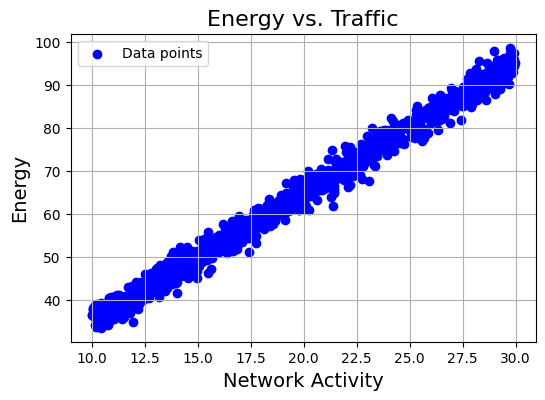

In [3]:
# Load data
data = pd.read_csv('regression.csv')

# Plot the data
plt.figure(figsize=(6, 4))
plt.scatter(data['Net_Activity'], data['Energy'], c='blue', label='Data points')
plt.grid(True)
plt.xlabel('Network Activity', fontsize=14)
plt.ylabel('Energy', fontsize=14)
plt.title('Energy vs. Traffic', fontsize=16)
plt.legend()
plt.show()

In [4]:
X_train = data[["Net_Activity"]].to_numpy()
y_train = data["Energy"].to_numpy()

model = LinearRegression(n_iterations=20)
model.fit(X_train, y_train)

print(
    f"Power consumption = "
    f"{model.weights[0]:.4f} * network activity "
    f"+ {model.bias:.4f}"
)

# visualize
plt.plot(model.loss_history)
plt.xlabel("Iteration")
plt.ylabel("Mean Squared Error")
plt.title("Training loss")
plt.show()


# visualize again
y_pred = model.predict(X_train)

plt.scatter(X_train[:, 0], y_train, alpha=0.5, label="Observed")
plt.plot(X_train[:, 0], y_pred, color="red", label="Linear regression")

plt.xlabel("Network activity")
plt.ylabel("Power consumption")
plt.legend()
plt.show()

NameError: name 'LinearRegression' is not defined

### ❓ Is the training loss curve stable?

Yes. The loss drops quickly at the start and then flattens out. There are no big jumps or oscillations, so the training looks stable and the learning rate seems reasonable.

### ❓ Derive the resulting energy consumption formula

The linear regression model is:

> `ŷ = wx + b`

With the learned values:

> `w = 3.2273`
> `b = 0.1562`

So the final formula is:

> `P̂ = 3.2273A + 0.1562`

where A is the network activity and P̂ is the predicted power consumption.

### ❓ Analyze prediction error distribution. What is an unbiased estimator?

The prediction errors looks evenly distributed around the regression line. There is no obvious pattern where the model is always predicting too high or too low.

An unbiased estimator is one that on average gives the true value of what we are trying to estimate. For this model, having prediction errors centered around zero suggests that there is no clear systematic bias.

### ❓ What does it tell you when the gradient in SGD is close to zero?

When the gradient gets close to zero, changing the weights will barely change the loss anymore. This usually means that SGD is close to or has reached a minimum.

For linear regression with MSE, the loss function is convex, so this should mean that the model is close to the global minimum.

## 🔋 Problem 2: Logistic regression

### Your task
1. Implement logistic regression
2. Train your model on binary classification data
3. Engineer features to improve the model's performance

### Formal requirements
1. **Implementation**:
   - Same as before, use standard libraries
   - Implement gradient descent

2. **Performance**: Achieve at least **0.88** classification accuracy on the test set

3. **Discussion**:
   - Explain poor initial performance and your improvements
   - What is the model's inductive bias. Why is it important?
   - Plot the ROC curve, what does the area under the curve measure?

In [ ]:
data = pd.read_csv('classification.csv')
train = data[data['split'] == 'train']
test = data[data['split'] == 'test']

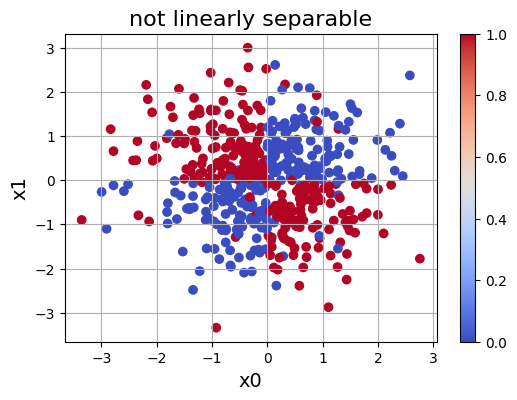

In [ ]:
# visualize x0 and x1 of train on scatterplot with colors corresponding to y
plt.figure(figsize=(6, 4))
plt.scatter(train['x0'], train['x1'], c=train['y'], cmap='coolwarm')
plt.grid(True)
plt.xlabel('x0', fontsize=14)
plt.ylabel('x1', fontsize=14)
plt.title('not linearly separable', fontsize=16)
plt.colorbar()
plt.show()

Baseline accuracy: 0.484
Train accuracy: 0.922
Test accuracy: 0.908
AUC: 0.944


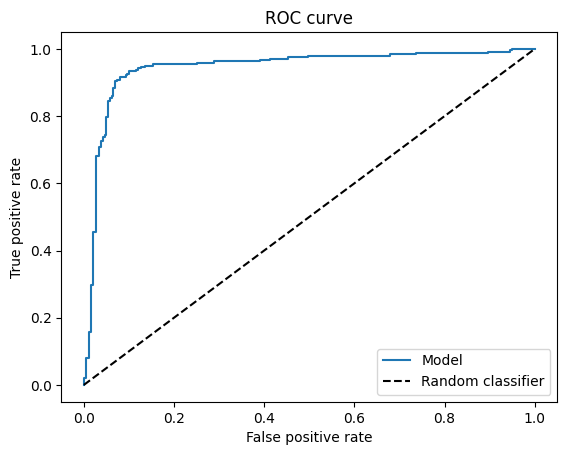

In [ ]:
from sklearn.metrics import roc_curve, auc

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

# Original features
X_train = train[['x0', 'x1']].to_numpy()
y_train = train['y'].to_numpy()

X_test = test[['x0', 'x1']].to_numpy()
y_test = test['y'].to_numpy()

# Standardize
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std


# --- Baseline model ---
baseline = LogisticRegression()
baseline.fit(X_train, y_train)

baseline_predictions = baseline.predict(X_test)

print("Baseline accuracy:", accuracy(y_test, baseline_predictions))

# Feature engineering

def engineer_features(X):
    x0 = X[:, 0]
    x1 = X[:, 1]

    return np.column_stack([
        # degree 1
        x0,
        x1,

        # degree 2
        x0 * x1,
        x0 ** 2,
        x1 ** 2,

        # degree 3
        x0 ** 3,
        x0 ** 2 * x1,
        x0 * x1 ** 2,
        x1 ** 3,
    ])


X_train = engineer_features(X_train)
X_test = engineer_features(X_test)


# --- Improved model ---

model = LogisticRegression(lr=0.5)
model.fit(X_train, y_train)

train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

y_score = model.predict_proba(
    X_test
)

print("Train accuracy:", accuracy(y_train, train_predictions))
print("Test accuracy:", accuracy(y_test, test_predictions))


# --- ROC curve ---
fpr, tpr, _ = roc_curve(
    y_test,
    y_score
)

roc_auc = auc(
    fpr,
    tpr
)

print(f"AUC: {roc_auc:.3f}")

plt.plot(fpr, tpr, label="Model")
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")

plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curve")
plt.legend()

plt.show()

### ❓ Explain poor initial performance and your improvements

The first model had poor performance because logistic regression with only `x0` and `x1` can only make a straight decision boundary. The data is not linearly separable, so that is just not enough. I improved it by adding polynomial and interaction features like `x0 * x1`, `x0^2`, `x1^2`, and some third-degree terms. That gives the model more flexibility and lets it represent a nonlinear boundary. The test accuracy improved from `0.484` to `0.908`.

### ❓ What is the model's inductive bias? Why is it important?

Logistic regression has a bias toward linear relationships in the features it is given. With only `x0` and `x1`, it basically assumes that a straight line should be enough to separate the classes. That assumption was not a good fit for this dataset. After adding nonlinear features, the model could still use logistic regression, but on a better representation of the data.

Inductive bias is important because it affects what kinds of patterns a model can learn easily and how well it generalizes.

### ❓ What does the area under the ROC curve measure?

The ROC curve shows how the true positive rate and false positive rate change when the classification threshold changes.

The AUC is the area under that curve. It gives a general measure of how well the model separates the two classes.

An AUC of `0.500` is about the same as random guessing, while `1.000` is perfect separation. Here the AUC is `0.944`, so the model separates the classes quite well.